<a href="https://colab.research.google.com/github/Ridzzz0Alam/data_cleaning_and_preprocessing/blob/main/Ridwan_Alam_assignment07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment – 07: Regression Models Comparison

## Dataset: Gender Recognition by Voice

SO the goal of this assisgnemnt is to Predict the label (Male = 1, Female =0) from extracted audio featuring using the technigque of **distance based regression model (K - Nearest Neighbors Regressor)**

The `KNN REgressor` averages the labesl of the K nearest neighbors, so a prediction is a number between 0 and 1. We are then going to measure how far those predictions land fron the true 0/1 values using **RMSE** and **MAE**.

## Process to be followed in tis notebook

1. **Data Understanding & preperation** - Exploring, Cleaning and scaling the features.
2. **KNN Modeling** - Sweep many `K values` and several `distance metrics`.
3. **Evaluraiotion** - Checking the score of every onfiguratrion with `RMSE` and `MAE` and comapre them.
4. Identifying and justification of the `best` configuration from the expirements.
5. **Conclusion/Explanation** - A short `personal explanation` of the final choice, based on results.  

# Imports and Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Libraries loaded.")

Libraries loaded.


# Data Preperation & Understanding

Loading the given data set to check the size, types and the cleaniness

In [4]:
df = pd.read_csv("/content/vocal_gender_features_new - vocal_gender_features_new.csv")
print("Shape:", df.shape)
df.head()

Shape: (16148, 44)


,mean_spectral_centroid,std_spectral_centroid,mean_spectral_bandwidth,std_spectral_bandwidth,mean_spectral_contrast,mean_spectral_flatness,mean_spectral_rolloff,zero_crossing_rate,rms_energy,mean_pitch,...,mfcc_9_std,mfcc_10_mean,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std,label
0,2247.331739,1158.537748,1870.415462,370.405241,21.440710,0.036879,4419.438073,0.169241,0.082552,1592.1033,...,21.736240,2.303085,8.983318,-17.410305,9.115154,0.301804,10.452693,-3.080832,10.146248,0
1,1790.719889,996.554825,1757.898617,410.710318,21.513383,0.018936,3635.742188,0.108068,0.055477,1112.6351,...,13.937135,-0.953942,10.831742,-0.088775,10.297690,-7.281142,10.926579,-0.450248,8.489134,0
2,1977.923363,1010.148667,1747.099555,461.458379,20.476283,0.032616,3873.291016,0.144633,0.060388,1557.5225,...,14.900779,0.260098,14.031009,-0.420670,10.810292,-0.199829,11.986182,3.372986,9.285437,0
3,2037.765550,1311.440630,1745.224852,419.056484,19.516014,0.028482,3826.584507,0.148933,0.029559,1481.0868,...,15.957924,-1.486122,14.461978,-8.479608,12.550333,3.997028,9.912608,-6.946966,10.574301,0
4,1739.383829,1092.623322,1623.135563,450.088465,20.260620,0.025737,3452.903892,0.117961,0.069078,1424.5352,...,15.105562,-3.366364,13.943447,-6.561539,11.944948,1.410639,13.110976,-3.252258,9.866687,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16148 entries, 0 to 16147
Data columns (total 44 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean_spectral_centroid   16148 non-null  float64
 1   std_spectral_centroid    16148 non-null  float64
 2   mean_spectral_bandwidth  16148 non-null  float64
 3   std_spectral_bandwidth   16148 non-null  float64
 4   mean_spectral_contrast   16148 non-null  float64
 5   mean_spectral_flatness   16148 non-null  float64
 6   mean_spectral_rolloff    16148 non-null  float64
 7   zero_crossing_rate       16148 non-null  float64
 8   rms_energy               16148 non-null  float64
 9   mean_pitch               16148 non-null  float64
 10  min_pitch                16148 non-null  float64
 11  max_pitch                16148 non-null  float64
 12  std_pitch                16148 non-null  float64
 13  spectral_skew            16148 non-null  float64
 14  spectral_kurtosis     

## 1.1 Missing values and duplicates

Distacne based models are sensitive to junk, so I checked the missing values and exact duplicate rows before anything else

In [6]:
print("Total missing values:", df.isna().sum().sum())
print("Exact duplicate rows :", df.duplicated().sum())

Total missing values: 0
Exact duplicate rows : 1078


As there are no missing values, but there are 1078 rows which are duplicate. Duplciates are a problem for KNN. If identical rows end up on both sides of the train/test split, the model looks better because a test point can find a perfect copy of itself among the training neighbors. SO i will have to drop the duplicate rows

In [7]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - len(df)} duplicate rows. New shape: {df.shape}")

Dropped 1078 duplicate rows. New shape: (15070, 44)


## 1.2 Targeting Label

The assignment mentions that Label is the target, so I check how balnaced the two classes are

label
0    5229
1    9841
Name: count, dtype: int64

Proportion male (1): 0.653


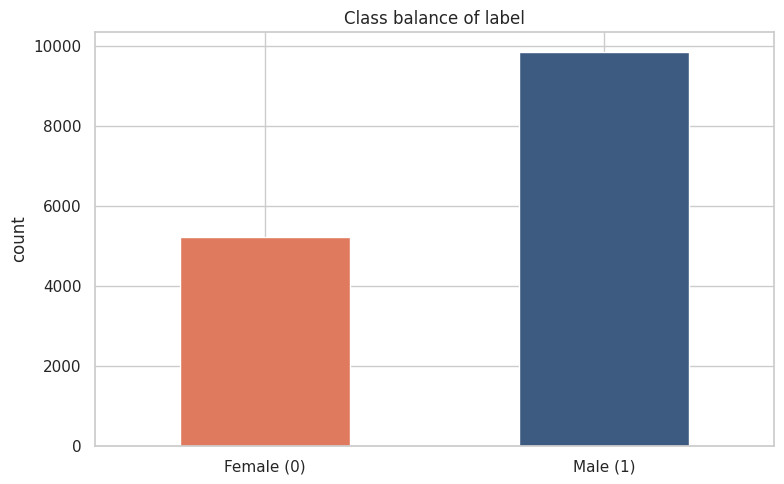

In [8]:
counts = df["label"].value_counts().sort_index()
print(counts)
print("\nProportion male (1):", round(df["label"].mean(), 3))

ax = counts.rename({0: "Female (0)", 1: "Male (1)"}).plot(kind="bar", color=["#e07a5f", "#3d5a80"])
ax.set_title("Class balance of label")
ax.set_ylabel("count"); ax.set_xlabel("")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

As expected the classes are imbalance that is there is more male samples then femal samples. This matters for interpretation wherein a model that leans toward predicting values are near the majority (male in this case) can still get a deceptively low error. So for this I will be using a `statified split` later on when reading `RMSE/MAE` so both sets keep the same male/female ratio.

## 1.3 Features Scale: Scaling is a must in this case

KNN Measure distance between points. If one feature ranges in the thousands and another ranges around 0.01, tehn in this case the large scale feature completely dominates the distance and the small ones are ignored. So I will be using row range to balance it.

In [9]:
feature_cols = [c for c in df.columns if c != "label"]
scale_view = df[feature_cols].agg(["min", "max", "mean", "std"]).T
scale_view["range"] = scale_view["max"] - scale_view["min"]
scale_view.sort_values("range", ascending=False).head(12)

,min,max,mean,std,range
mean_spectral_rolloff,1310.661765,5451.099537,3268.907144,532.560286,4140.437772
mean_spectral_centroid,719.559285,3059.390150,1701.384153,317.899605,2339.830865
max_pitch,1794.782000,3996.093800,3980.640005,86.716053,2201.311800
mean_pitch,359.391170,2454.724000,1452.435740,289.350721,2095.332830
std_spectral_centroid,194.998983,1912.173446,1018.110186,285.942121,1717.174463
std_pitch,204.092130,1596.422400,1152.283125,142.010429,1392.330270
mean_spectral_bandwidth,1106.939002,2046.070801,1584.749875,128.309386,939.131799
std_spectral_bandwidth,199.321584,724.361505,428.708065,75.195519,525.039921
mfcc_1_mean,-448.921970,-162.769840,-256.379063,37.468513,286.152130
mfcc_1_std,52.445877,206.839600,118.555894,20.621734,154.393723


The ranges span from thousands in pitch, rolloff and centroid down to hundreds. Some fatures are 1000 times larger than others. So **standardisation** is required for a distacne based model. That is why I have used `StandardScaler` only on the training set to avoid leaking test infromation into the scaler.

## 1.4 Look at other feature distributions

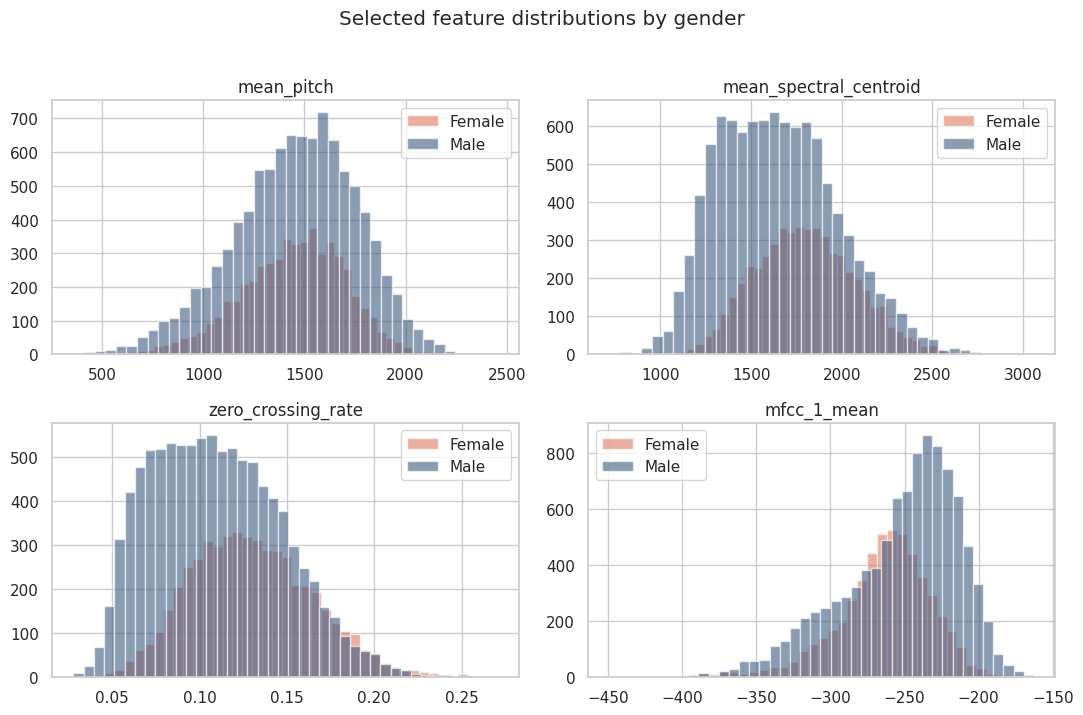

In [10]:
example_feats = ["mean_pitch", "mean_spectral_centroid", "zero_crossing_rate", "mfcc_1_mean"]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, feat in zip(axes.ravel(), example_feats):
    for lab, color, name in [(0, "#e07a5f", "Female"), (1, "#3d5a80", "Male")]:
        ax.hist(df.loc[df.label == lab, feat], bins=40, alpha=0.6, color=color, label=name)
    ax.set_title(feat); ax.legend()
fig.suptitle("Selected feature distributions by gender", y=1.02)
plt.tight_layout(); plt.show()

As from the graphs we can see that `mean_pitch` and `mean_spectral_centroid` seperate the two faily well, which is good as it suggest neighbors in feature space really to tend to share a gender, which is exaclty the assumption KNN relies on.

# 1.5 Correlation Overview

/tmp/ipykernel_1142/2182252893.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_label.values, y=corr_with_label.index, palette="vlag")


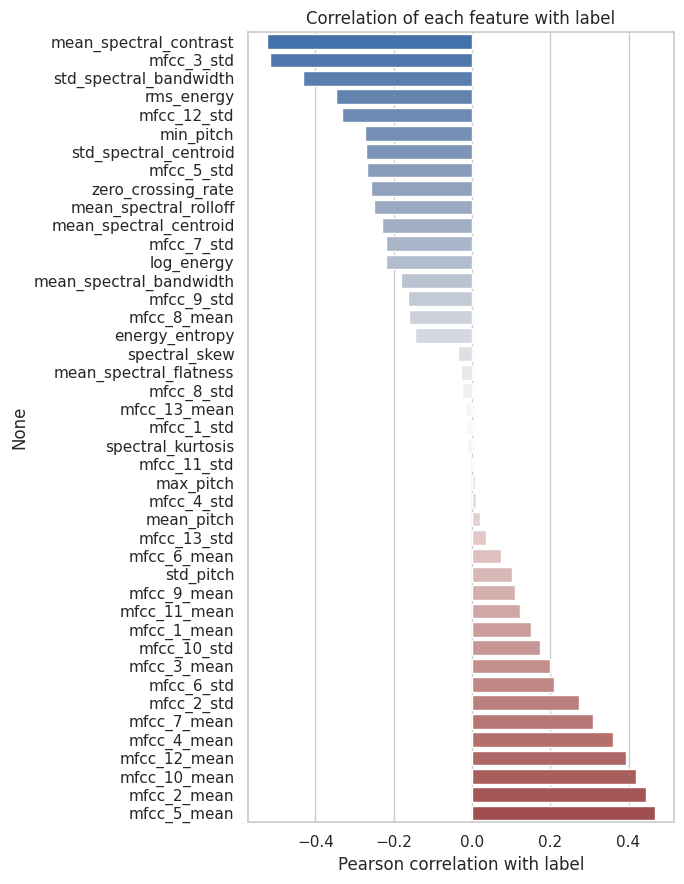

Most positively/negatively correlated features:
mean_spectral_contrast   -0.523588
mfcc_3_std               -0.515623
std_spectral_bandwidth   -0.432073
mfcc_10_mean              0.419576
mfcc_2_mean               0.444837
mfcc_5_mean               0.466618
Name: label, dtype: float64


In [11]:
corr_with_label = df.corr(numeric_only=True)["label"].drop("label").sort_values()
plt.figure(figsize=(7, 9))
sns.barplot(x=corr_with_label.values, y=corr_with_label.index, palette="vlag")
plt.title("Correlation of each feature with label")
plt.xlabel("Pearson correlation with label"); plt.tight_layout(); plt.show()
print("Most positively/negatively correlated features:")
print(pd.concat([corr_with_label.head(3), corr_with_label.tail(3)]))

## 1.6 Train/Test split along with Scaling

SPliting before scaling and fiting the scalar on the training data only. I keep the split stratified so the class ratio is not touched

In [12]:
X = df[feature_cols].values
y = df["label"].values.astype(float)   # float because we treat this as regression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler().fit(X_train)      # fit on train only
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

print("Train:", X_train_s.shape, " Test:", X_test_s.shape)
print("Train mean ~0 check:", np.round(X_train_s.mean(axis=0)[:3], 4),
      " std ~1 check:", np.round(X_train_s.std(axis=0)[:3], 4))

Train: (12056, 43)  Test: (3014, 43)
Train mean ~0 check: [ 0.  0. -0.]  std ~1 check: [1. 1. 1.]


# 2. KNN Modeling: Sweeping K values and distnace metrics

A KNN regressor predicts a value by averaging the labels of teh K nearest training points. Two things matter the most in this case as well.

- KNN as small K mean flexible but noissy and lerge K is smooth but can be washed
- `distance metric` to check how nearness is defined. So I will be using
  - `euclidean` straight line, Minkowski p=2
  - `manhattan` city block, Minkowski p=1
  - `chebyshev` max coordinate difference
  - `cosine` angle between feature vectors rather than straight-line gap.

I will aslo try both `weighting schemas` in which the metrics such as `uniform` all the neighbors count and `distance` closest neighbor count more

For each of the configuration I record the RMSE and MAE on the test sets.

In [13]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31, 41, 51, 71, 101]
metrics  = ["euclidean", "manhattan", "chebyshev", "cosine"]
weights_options = ["uniform", "distance"]

records = []
for metric in metrics:
    for weights in weights_options:
        for k in k_values:
            model = KNeighborsRegressor(n_neighbors=k, metric=metric, weights=weights)
            model.fit(X_train_s, y_train)
            pred = model.predict(X_test_s)
            records.append({
                "metric": metric,
                "weights": weights,
                "K": k,
                "RMSE": rmse(y_test, pred),
                "MAE": mean_absolute_error(y_test, pred),
            })

results = pd.DataFrame(records)
print("Total configurations tried:", len(results))
results.head()

Total configurations tried: 104


,metric,weights,K,RMSE,MAE
0,euclidean,uniform,1,0.036430,0.001327
1,euclidean,uniform,3,0.033256,0.002433
2,euclidean,uniform,5,0.036972,0.003517
3,euclidean,uniform,7,0.035488,0.003602
4,euclidean,uniform,9,0.036261,0.004166


## 2.1 RMSE vs K for each distance metric

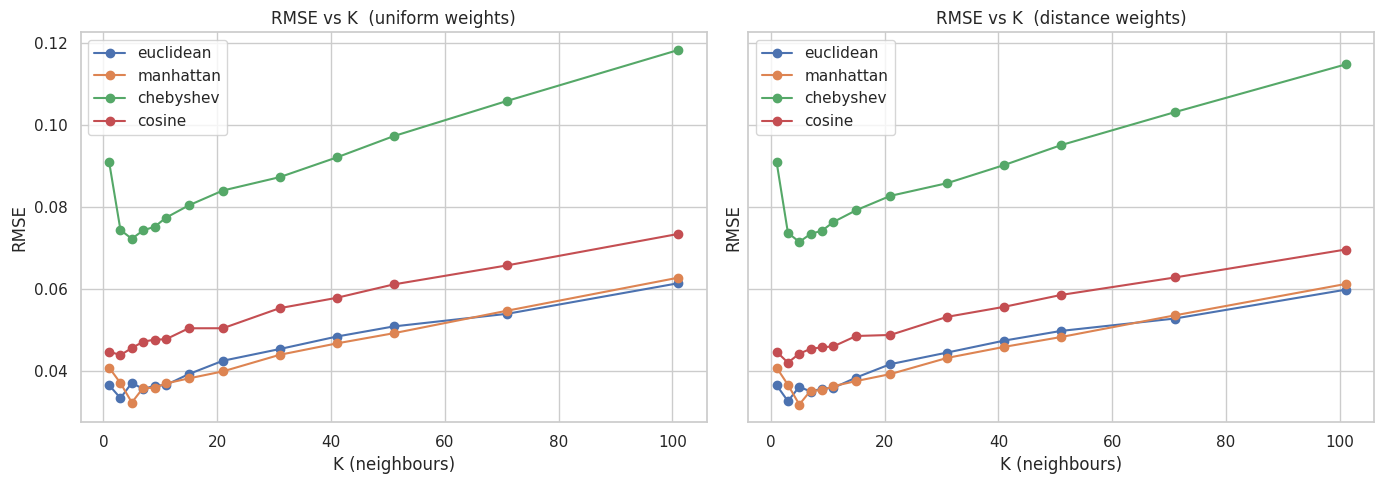

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, w in zip(axes, ["uniform", "distance"]):
    sub = results[results.weights == w]
    for metric in sub.metric.unique():
        m = sub[sub.metric == metric].sort_values("K")
        ax.plot(m.K, m.RMSE, marker="o", label=metric)
    ax.set_title(f"RMSE vs K  ({w} weights)")
    ax.set_xlabel("K (neighbours)"); ax.set_ylabel("RMSE"); ax.legend()
plt.tight_layout(); plt.show()

## 2.2 MAE vs K for ecah Distance Metric

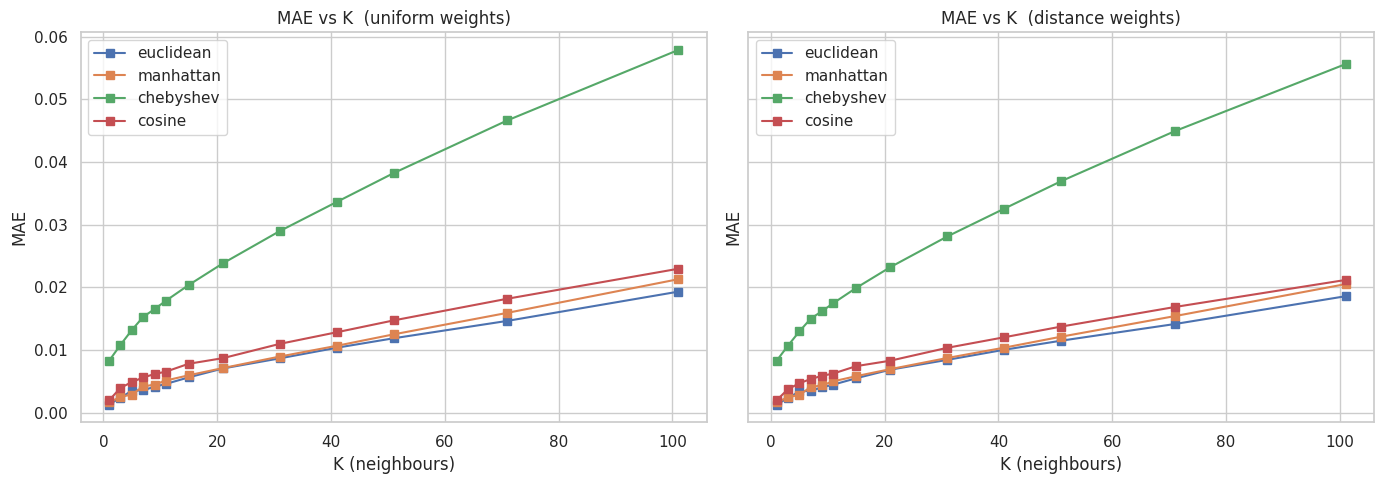

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, w in zip(axes, ["uniform", "distance"]):
    sub = results[results.weights == w]
    for metric in sub.metric.unique():
        m = sub[sub.metric == metric].sort_values("K")
        ax.plot(m.K, m.MAE, marker="s", label=metric)
    ax.set_title(f"MAE vs K  ({w} weights)")
    ax.set_xlabel("K (neighbours)"); ax.set_ylabel("MAE"); ax.legend()
plt.tight_layout(); plt.show()

# 3. Evaluation: RMSE and MAE

So I have used bot the metrics to find the following

- **MAE** (mean absolute error) is the average size of the mistake where every erros counts here
- **RMSE** (root mean squared error) squares the errors before averaging so the large mistakes could be found out.

Since our true labels are 0/1 and prediction lives in [0,1] a large mistake could mean a point where the model is confiently wrong (For example 0.9 for a female voice)

Now a few considerations to keep in mind:
- If **RMSE and MAE agress** that means both point to the same K, the errors are fairly uniform in size in that case.
- **IF THEY DISAGREE** in a scenario where setting has a good MAE but a worse RMSE it means one of the following
  - *more large, confident errors*, evne though its error is small RMSE catches what MAE is hiding.

Below I find the best configuration under each metrics and check whether they agree or not.



In [16]:
best_by_rmse = results.sort_values("RMSE").head(5).reset_index(drop=True)
best_by_mae  = results.sort_values("MAE").head(5).reset_index(drop=True)

print("Top 5 configurations by RMSE:")
display(best_by_rmse)
print("\nTop 5 configurations by MAE:")
display(best_by_mae)

Top 5 configurations by RMSE:


,metric,weights,K,RMSE,MAE
0,manhattan,distance,5,0.031684,0.002858
1,manhattan,uniform,5,0.032174,0.002920
2,euclidean,distance,3,0.032507,0.002356
3,euclidean,uniform,3,0.033256,0.002433
4,euclidean,distance,7,0.034838,0.003521



Top 5 configurations by MAE:


,metric,weights,K,RMSE,MAE
0,euclidean,uniform,1,0.036430,0.001327
1,euclidean,distance,1,0.036430,0.001327
2,manhattan,uniform,1,0.040730,0.001659
3,manhattan,distance,1,0.040730,0.001659
4,cosine,distance,1,0.044617,0.001991


In [18]:
top_rmse = results.loc[results.RMSE.idxmin()]
top_mae  = results.loc[results.MAE.idxmin()]

def fmt(row):
    return {"metric": row.metric, "weights": row.weights, "K": int(row.K),
            "RMSE": round(row.RMSE, 4), "MAE": round(row.MAE, 4)}

print("Best by RMSE ->", fmt(top_rmse))
print("Best by MAE  ->", fmt(top_mae))
agree = (top_rmse[["metric","weights","K"]] == top_mae[["metric","weights","K"]]).all()
print("\nDoes RMSE and MAE pick the SAME configuration?", bool(agree))

Best by RMSE -> {'metric': 'manhattan', 'weights': 'distance', 'K': 5, 'RMSE': np.float64(0.0317), 'MAE': np.float64(0.0029)}
Best by MAE  -> {'metric': 'euclidean', 'weights': 'uniform', 'K': 1, 'RMSE': np.float64(0.0364), 'MAE': np.float64(0.0013)}

Does RMSE and MAE pick the SAME configuration? False


## 3.1 Finding out where both the two metrics disagree

I will now compute **ratio RMSE / MAE** for every settings. A higher ratio means that the settings error are more large. A few large confident mistakes inflating RMSE relative to MAE. This is exactly the kind of dissagreemnt this assignment wants me to work with.

Average RMSE/MAE ratio by metric & weighting (higher = more large, confident errors):
metric     weights 
euclidean  distance    8.661
           uniform     8.613
manhattan  distance    8.136
           uniform     8.086
cosine     distance    7.669
           uniform     7.585
chebyshev  distance    4.422
           uniform     4.393
Name: RMSE_over_MAE, dtype: float64


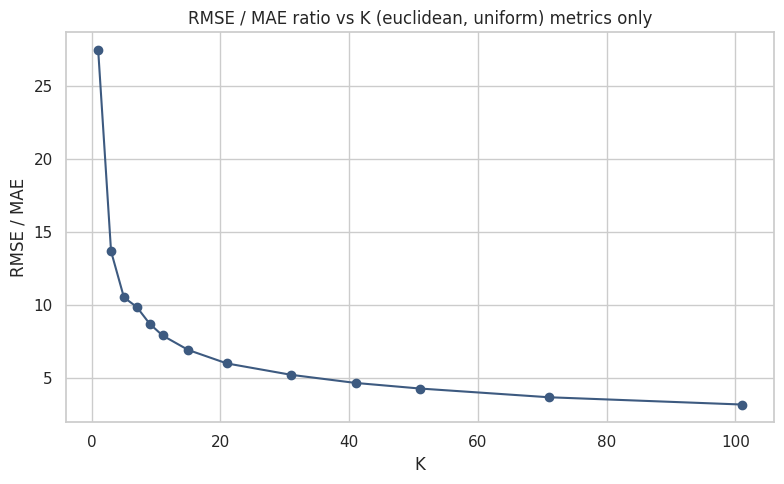

In [20]:
results["RMSE_over_MAE"] = results.RMSE / results.MAE
ratio_view = results.groupby(["metric", "weights"])["RMSE_over_MAE"].mean().sort_values(ascending=False)
print("Average RMSE/MAE ratio by metric & weighting (higher = more large, confident errors):")
print(ratio_view.round(3))

# how the ratio moves with K (uniform, euclidean) — small K = spikier errors
sub = results[(results.metric == "euclidean") & (results.weights == "uniform")].sort_values("K")
plt.plot(sub.K, sub.RMSE_over_MAE, marker="o", color="#3d5a80")
plt.title("RMSE / MAE ratio vs K (euclidean, uniform) metrics only")
plt.xlabel("K"); plt.ylabel("RMSE / MAE"); plt.tight_layout(); plt.show()

 From the graph I can interpret that at a very small K the RMSE/MAE ratio is highest with K=1 the model copies a single neighbour, so when that neighbour is the wrong gender the model is 100% wrong on the point(a big squared error). AS K gwos the predictions become averaged fractions, the huge individual erros decrease, and the raio comes down. This means that "RMSE punishing mistakes" and small K models make more of them.

# 4. Identifying and justifying the best configuration model


From the expirements the single best model is the not a good practice as there could be several other factors affecting the score and so on from one particular split. So I will take the top 5 candidates and re-score them with 5 fold cross validation on the training set.

So among this whichever holds the best will be my best pick, after this I check its test set numbers for confirmation.

In [21]:
candidates = pd.concat([best_by_rmse, best_by_mae]).drop_duplicates(
    subset=["metric", "weights", "K"]).reset_index(drop=True)

def make_model(row):
    return KNeighborsRegressor(n_neighbors=int(row.K), weights=row.weights, metric=row.metric)

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for _, row in candidates.iterrows():
    model = make_model(row)
    scores = cross_val_score(model, X_train_s, y_train, cv=cv,
                             scoring="neg_root_mean_squared_error")
    cv_rows.append({**row[["metric","weights","K"]].to_dict(),
                    "CV_RMSE_mean": -scores.mean(),
                    "CV_RMSE_std": scores.std()})

cv_results = pd.DataFrame(cv_rows).sort_values("CV_RMSE_mean").reset_index(drop=True)
cv_results.round(4)

,metric,weights,K,CV_RMSE_mean,CV_RMSE_std
0,euclidean,distance,7,0.0360,0.0037
1,manhattan,distance,5,0.0366,0.0027
2,manhattan,uniform,5,0.0370,0.0027
3,euclidean,distance,3,0.0379,0.0036
4,euclidean,uniform,3,0.0382,0.0036
5,manhattan,uniform,1,0.0419,0.0084
6,manhattan,distance,1,0.0419,0.0084
7,euclidean,uniform,1,0.0466,0.0082
8,euclidean,distance,1,0.0466,0.0082
9,cosine,distance,1,0.0554,0.0092


In [22]:
best = cv_results.iloc[0]
print("Chosen configuration (best cross-validated RMSE):")
print({"metric": best.metric, "weights": best.weights, "K": int(best.K),
       "CV_RMSE_mean": round(best.CV_RMSE_mean, 4), "CV_RMSE_std": round(best.CV_RMSE_std, 4)})

final_model = make_model(best)
final_model.fit(X_train_s, y_train)
final_pred = final_model.predict(X_test_s)

final_rmse = rmse(y_test, final_pred)
final_mae  = mean_absolute_error(y_test, final_pred)
print(f"\nFinal held-out TEST RMSE: {final_rmse:.4f}")
print(f"Final held-out TEST MAE : {final_mae:.4f}")

Chosen configuration (best cross-validated RMSE):
{'metric': 'euclidean', 'weights': 'distance', 'K': 7, 'CV_RMSE_mean': np.float64(0.036), 'CV_RMSE_std': np.float64(0.0037)}

Final held-out TEST RMSE: 0.0348
Final held-out TEST MAE : 0.0035


## 4.1 What the best models prdiction looks like

Since it is a regressor and not a classifier so it doesnt outputs 0 or 1 directly but outputs a continous number that would be the average label of the K nearest neighbours. A value near 0 means most nearby voices were female, near 1 means most were male and for something like 0.5 means the neighbours were split

To connect this back to something intiutive I convert each prediction into a hard class guess by `thresholding at 0.5`and for anything above >0.5 will be called **male** and anything below it will be called **female**.

Comparing these guesses to the true lables gives a plain accuracy socre. This isn't the metric the model was optimized for but it is a good thing to check if the accuracy looks reasonable through which it confirms that the model is seperating the two genders well.

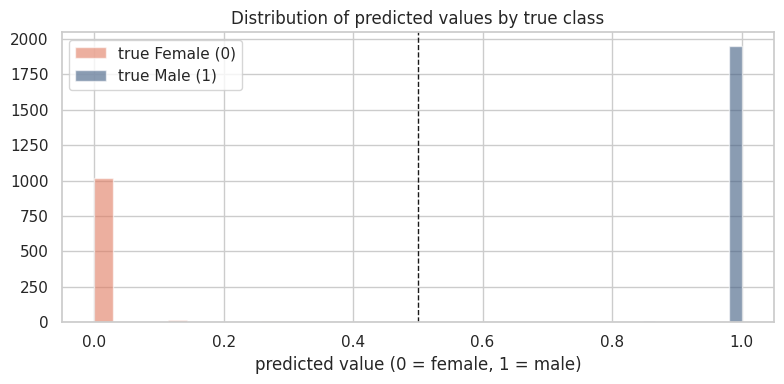

Accuracy if thresholded at 0.5: 0.9987


In [23]:
plt.figure(figsize=(8,4))
plt.hist(final_pred[y_test == 0], bins=30, alpha=0.6, color="#e07a5f", label="true Female (0)")
plt.hist(final_pred[y_test == 1], bins=30, alpha=0.6, color="#3d5a80", label="true Male (1)")
plt.axvline(0.5, color="k", ls="--", lw=1)
plt.title("Distribution of predicted values by true class")
plt.xlabel("predicted value (0 = female, 1 = male)"); plt.legend()
plt.tight_layout(); plt.show()

acc = ((final_pred >= 0.5).astype(int) == y_test.astype(int)).mean()
print(f"Accuracy if thresholded at 0.5: {acc:.4f}")

As from the graph we can see that the 2 colored lines sit on the two opposite sides of the 0.5 line, from this we can confirm that the regressor seperates the gender well. The overlap in the mdiddle is where the confident mistake lies which is the RMSE in this case.

# 5. My Explanaton and why I picked this model


- So when I started working I noticed was that the features were on a different scale, some in thousands and some as small as 0.2. Since KNN works by measruing distance, the big number features would completely dominate if I didnt scale everything first. So that is why scaling is an important step and not optional.

- I also removed the 1078 duplicate rows, becasue a duplicate showing up in both train and test would let the model cheat by itself by mathcing itslef with the traing data

- For the modeling part, I didnt want to just pick one setting and hope it was good, so I tried many values of K along with differnet distance metrics and 2 weighting options that showed 104 Combinations in total.

- One thing I learned was that the MAE and RMSE didnt agree in the best K as MAE was lowest at K = 1 nad kept getting worst as K increased. RMSE on the other hand was lowest at K=3 and not in K=1. Both the metrics did agree that very large K is bad and the value of K=15 both the erros kept climbing.

- The disagreeemnt between RMSE and MAE at small K is the part I found most interesting. RMSE punihsed big mistakes too much than MAE does as it squares hte erorrs. At K=1 the model just copies its single nearest neighbour, so when that one neighbour happens to be the wrong gender, the prediction is completely wrong. Usually this kind of full size mistake barely affects MAE, but it makes RMSE much worse so when K=1 looks great on average error, but its actually making more of these bad confident mistakes. But one thing I kept in my mind was that being confidently wrong is more worst than being a little wrong, So I paid more attendtion and avoided taking K=1

- Finally to pick the model based on test split, I used 5 fold cross validation on the top candidates and let that decide the results. From which it choose K=7 with euclidean distance and distacne based weighting. So based on all these matches my reasoning and final results.